# USA Regional Sales Analysis

## Project Summary
This EDA explores Acme Co.’s 2014–2018 U.S. sales data, covering data cleaning, distribution analysis, trends, and customer segmentation. It highlights key patterns in revenue, pricing, and margins, along with seasonal shifts and unusual transactions.

## Problem Statement
Analyze historical sales data to uncover the main drivers of revenue and profit across products, regions, and channels. Identify trends, outliers, and gaps against budgets to support better pricing, promotion, and expansion decisions.

## Objective
- Identify top-performing products, regions, and sales channels  
- Detect seasonal patterns and irregularities  
- Highlight pricing and margin risks  
- Support data-driven decisions for growth and market expansion  

Insights will be used to build a Power BI dashboard for strategic planning.

# Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
sheets = pd.read_excel('Regional Sales Dataset.xlsx',sheet_name = None)

# Data Ingestion

In [3]:
# assighning daata frames to each sheets

df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_products = sheets['Products']
df_regions = sheets['Regions']
df_state_reg = sheets['State Regions']
df_budget = sheets['2017 Budgets']

# Data Profiling / Initial Inspection

In [4]:
#  QUICK SHAPE OVERVIEW
print(f"df_sales      shape: {df_sales.shape}      ")
print(f"df_customers  shape: {df_customers.shape}  ")
print(f"df_products   shape: {df_products.shape}   ")
print(f"df_regions    shape: {df_regions.shape}    ")
print(f"df_state_reg  shape: {df_state_reg.shape}  ")
print(f"df_budget     shape: {df_budget.shape}     ")

df_sales      shape: (64104, 12)      
df_customers  shape: (175, 2)  
df_products   shape: (30, 2)   
df_regions    shape: (994, 15)    
df_state_reg  shape: (49, 3)  
df_budget     shape: (30, 2)     


In [5]:
# data overview
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [6]:
# — QUICK VIEW OF ALL RAW DATAFRAMES
# Print first few rows for each sheet

print("\n— df_sales head —")
display(df_sales.head())
print()

print("\n— df_customers head —")
display(df_customers.head())
print()

print("\n— df_products head —")
display(df_products.head())
print()

print("\n— df_regions head —")
display(df_regions.head())
print()

print("\n— df_state_reg head —")
display(df_state_reg.head())
print()

print("\n— df_budgets head —")
display(df_budget.head())


— df_sales head —


,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270




— df_customers head —


,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd




— df_products head —


...

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago




— df_state_reg head —


,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West




— df_budgets head —


,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [7]:
#null check

In [8]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [9]:
df_customers.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

In [10]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [11]:
df_regions.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

In [12]:
df_state_reg.isnull().sum()

Column1    0
Column2    0
Column3    0
dtype: int64

In [13]:
df_budget.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

# data cleaning and wrangling

In [14]:
#merge with customers

df = df_sales.merge(
    df_customers,
    how = 'left',
    left_on = 'Customer Name Index',
    right_on = 'Customer Index'
)

In [15]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


# fixing column name issues 

In [16]:
header = df_state_reg.iloc[0]

df_state_reg.columns = header
df_state_reg = df_state_reg[1:]
df_state_reg = df_state_reg.reset_index(drop=True)


df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


# Merging data 
Merging different sheets to a single, consolidated master view, enabling easier data analysis, reporting, and tracking across multiple sources

In [17]:
#merge with products

df  = df.merge(
    df_products,
    how = 'left',
    left_on = 'Product Description Index',
    right_on = 'Index'
)

In [18]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [19]:
#merge with regions

df  = df.merge(
    df_regions,
    how = 'left',
    left_on = 'Delivery Region Index',
    right_on = 'id'
)

In [20]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [21]:
#merge with state regions

df = df.merge(
    df_state_reg[["State Code","Region"]],
    how='left',
    left_on='state_code',
    right_on='State Code',
)

In [22]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [23]:
#merge with budgets

df = df.merge(
    df_budget,
    how='left',
    left_on='Product Name',
    right_on='Product Name'
)

In [24]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [25]:
#clean redundent columns
#Customer Index,Index,id
# del later how do we decide what to drop after merge

cols_to_drop = ['Customer Index','Index','id']
df = df.drop(columns = cols_to_drop,errors = 'ignore')

df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [26]:
#convert all columns to lower case for consistancy and easier access

df.columns = df.columns.str.lower()
df.columns.values


array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone',
       'state code', 'region', '2017 budgets'], dtype=object)

In [27]:
#Retain the important columns and delete the unimportant ones.

cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'product name',
    'order quantity',
    'unit price',
    'line total',
    'state',
    'total unit cost',
    'state_code',
    'county',
    'region',
    'latitude',
    'longitude',
    'population',
    '2017 budgets'
]

In [28]:
df = df[cols_to_keep]

In [29]:
df.head(5)

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,state,total unit cost,state_code,county,region,latitude,longitude,population,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,Georgia,1824.343,GA,Chatham County,South,32.08354,-81.09983,145674,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,Indiana,1269.918,IN,Johnson County,Midwest,39.61366,-86.10665,55586,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,California,684.740,CA,Alameda County,West,37.66243,-121.87468,79510,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,Indiana,1028.852,IN,Monroe County,Midwest,39.16533,-86.52639,84067,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,Connecticut,1260.270,CT,Hartford County,Northeast,41.77524,-72.52443,58007,1085037.329


In [30]:
df= df.rename(columns = 
              {
                  'ordernumber' : 'order_number',
                  'orderdate' : 'order_date',
                  'customer names' : 'customer_names',
                  'product name' : 'product_name',
                  'order quantity' : 'order_quantity',
                  'unit price' : 'unit price',
                  'line total' : 'revenue',
                  'total unit cost' : 'cost',
                  'state_code' : 'state_code',
                  'state' : 'state_name',
                  '2017 budgets' : 'budget'
                  
              }
    
)
df.head(1)

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit price,revenue,state_name,cost,state_code,county,region,latitude,longitude,population,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,Georgia,1824.343,GA,Chatham County,South,32.08354,-81.09983,145674,964940.231


In [31]:
# since we are working with 2017 data we need to convert non 2017 data to be null

df.loc[df['order_date'].dt.year != 2017,'budget',] = pd.NA

df[['order_date','product_name','revenue','budget']].head(5)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [32]:
df.info

<bound method DataFrame.info of        order_number order_date    customer_names      channel product_name  \
0       SO - 000225 2014-01-01     Rhynoodle Ltd    Wholesale   Product 27   
1      SO - 0003378 2014-01-01    Thoughtmix Ltd  Distributor   Product 20   
2      SO - 0005126 2014-01-01   Amerisourc Corp    Wholesale   Product 26   
3      SO - 0005614 2014-01-01  Colgate-Pa Group       Export    Product 7   
4      SO - 0005781 2014-01-01     Deseret Group    Wholesale    Product 8   
...             ...        ...               ...          ...          ...   
64099  SO - 0007573 2018-02-28   Dazzlesphe Corp    Wholesale   Product 26   
64100  SO - 0007706 2018-02-28        Yombu Corp       Export   Product 21   
64101  SO - 0007718 2018-02-28        Bath Group  Distributor   Product 13   
64102  SO - 0008084 2018-02-28     Linklinks Ltd  Distributor   Product 20   
64103  SO - 0008654 2018-02-28       SAFEWAY Ltd  Distributor   Product 15   

       order_quantity  unit pri

In [33]:
df_2017 = df[df['order_date'].dt.year == 2017]

In [34]:
df.isnull().sum()

order_number          0
order_date            0
customer_names        0
channel               0
product_name          0
order_quantity        0
unit price            0
revenue               0
state_name            0
cost                  0
state_code            0
county                0
region                0
latitude              0
longitude             0
population            0
budget            48841
dtype: int64

In [35]:
df_2017.head(5)

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit price,revenue,state_name,cost,state_code,county,region,latitude,longitude,population,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,New Jersey,1028.785,NJ,Hudson County,Northeast,40.77955,-74.02375,69156,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,Colorado,1207.206,CO,Mesa County,West,39.06387,-108.55065,60358,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,California,1664.280,CA,Los Angeles County,West,33.96168,-118.35313,111666,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,Iowa,750.735,IA,Dubuque County,Midwest,42.50056,-90.66457,58799,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,Florida,811.906,FL,Hernando County,South,28.47689,-82.52546,100270,3050087.565


# Feature Enginering

In [36]:
df.head(5)

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit price,revenue,state_name,cost,state_code,county,region,latitude,longitude,population,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,Georgia,1824.343,GA,Chatham County,South,32.08354,-81.09983,145674,NaN
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,Indiana,1269.918,IN,Johnson County,Midwest,39.61366,-86.10665,55586,NaN
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,California,684.740,CA,Alameda County,West,37.66243,-121.87468,79510,NaN
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,Indiana,1028.852,IN,Monroe County,Midwest,39.16533,-86.52639,84067,NaN
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,Connecticut,1260.270,CT,Hartford County,Northeast,41.77524,-72.52443,58007,NaN


In [37]:
df['total_cost'] = df['order_quantity'] * df['cost']

In [38]:
df['profit'] = df['revenue'] - df['total_cost']

df['profit_margin_pct'] = df['profit'] / df['revenue'] * 100

In [39]:
df.head()

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit price,revenue,state_name,cost,state_code,county,region,latitude,longitude,population,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,Georgia,1824.343,GA,Chatham County,South,32.08354,-81.09983,145674,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,Indiana,1269.918,IN,Johnson County,Midwest,39.61366,-86.10665,55586,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,California,684.740,CA,Alameda County,West,37.66243,-121.87468,79510,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,Indiana,1028.852,IN,Monroe County,Midwest,39.16533,-86.52639,84067,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,Connecticut,1260.270,CT,Hartford County,Northeast,41.77524,-72.52443,58007,NaN,10082.160,8249.040,45.0


# Exploratory Data Analysis 

# Monthly Sales Trend Over Time
Goal: Track revenue trends over time to detect seasonality or sales spikes

Chart: Line chart

EDA Type: Temporal (time series)

Structure: Line with markers to highlight monthly revenue points clearly

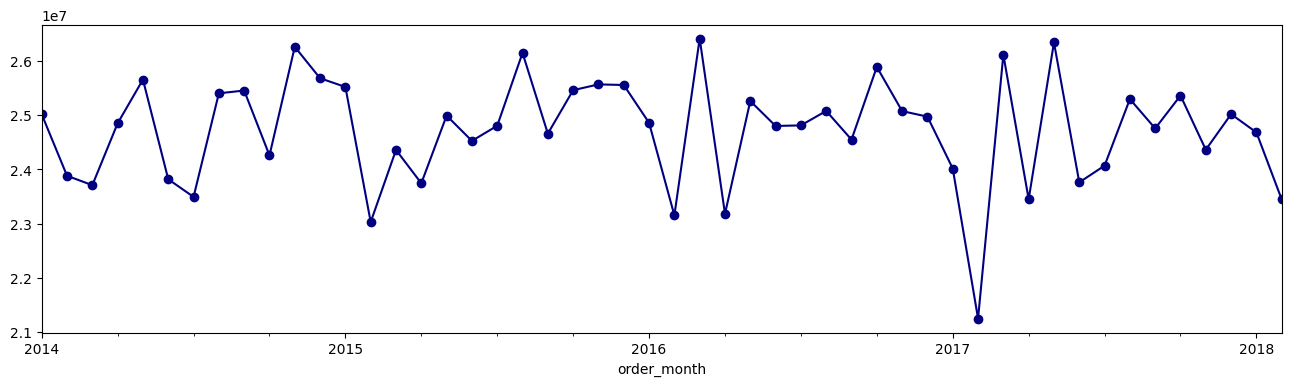

In [40]:
####  monthly analysis

df['order_month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('order_month')['revenue'].sum()

plt.figure(figsize=(16,4))

monthly_sales.plot(marker = 'o',color = 'navy')

from matplotlib.ticker import FuncFormatter
fromatter = FuncFormatter(lambda x,pos : f'{x/1e6 :. 1f}M')

# Insights

Sales show a consistent seasonal pattern, ranging between 24M and 26M. Revenue typically peaks during May–June and dips in January each year.

Overall, the trend remains stable across years, indicating predictable demand cycles.

However, a noticeable drop in early 2017 deviates from this pattern and should be investigated further, as it may be linked to external factors or ineffective business strategies.

# Top 10 Products by Revenue (in Millions)
Goal: Identify the highest-grossing products to focus marketing and inventory efforts

Chart: Horizontal bar chart

EDA Type: Univariate

Structure: Bars sorted descending to show top 10 products with revenue scaled in millions

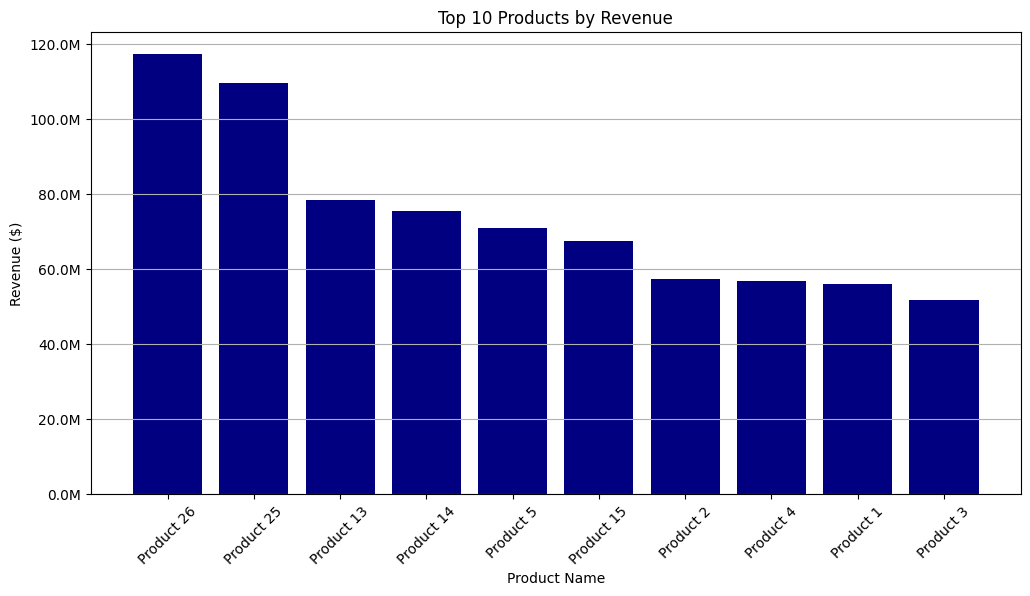

In [41]:
product_revenue = df.groupby('product_name')['revenue'].sum()

top_products = product_revenue.sort_values(ascending=False).head(10)

labels = top_products.index.tolist()
data = top_products.values.tolist()

plt.figure(figsize=(12,6))
plt.bar(labels, data, color='navy')

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Name")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

# Insight

Products 26, 25, and 13 are the top revenue contributors, consistently outperforming all other products over time. Their strong and stable sales patterns suggest high customer demand and market acceptance.

These products likely drive a significant share of overall revenue, making them critical to business performance. Any fluctuations in their sales can have a noticeable impact on total revenue.

Focus on growth pilots for the mid-tier and efficiency gains for the lower earners to drive significant lifts.

# Top 10 Products by Avg Profit Margin
Goal: Compare average profitability across products to identify high-margin items

Chart: Horizontal bar chart

EDA Type: Univariate

Structure: Bars sorted descending to show top 10 products with average profit margin values


C:\Users\mdf86\AppData\Local\Temp\ipykernel_21720\1094266072.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


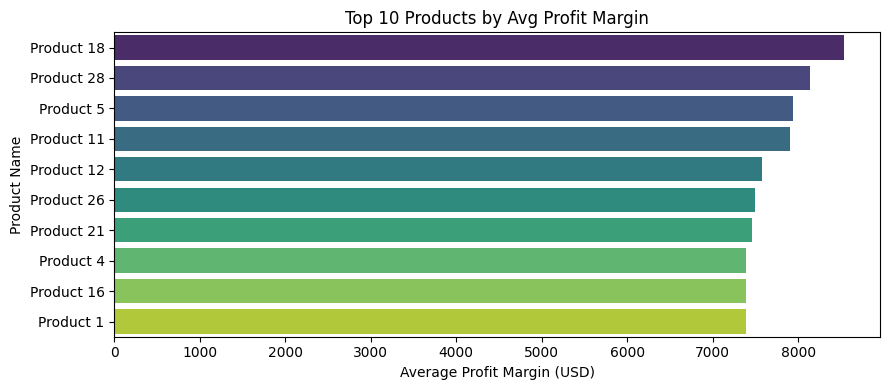

In [47]:
# Compute average profit per product and take the top 10
top_margin = (
    df.groupby('product_name')['profit']
      .mean()                     
      .sort_values(ascending=False) 
      .head(10)                      
)

plt.figure(figsize=(9, 4))

sns.barplot(
    x=top_margin.values,    
    y=top_margin.index,    
    palette='viridis'       
)


plt.title('Top 10 Products by Avg Profit Margin')  # Chart title
plt.xlabel('Average Profit Margin (USD)')          # X-axis label
plt.ylabel('Product Name')                         # Y-axis label

plt.tight_layout()
plt.show()

# Insights
Products 18 and 28 lead in average profit margins, reaching approximately 8.0–8.3K, with Products 5 and 11 following closely at around 7.9–8.0K.

Mid-tier performers, including Products 12, 26, and 21, cluster in the 7.7–7.8K range. In contrast, the lower-performing group—Products 4, 16, and 1—falls between 7.4–7.6K.

Focusing on margin optimization strategies used by the top-performing products could help improve overall product profitability.

# Sales by Channel

Goal: Show distribution of total sales across channels to identify dominant sales routes

Chart: Pie chart

EDA Type: Univariate

Structure: Pie segments with percentage labels, colors for clarity, start angle adjusted

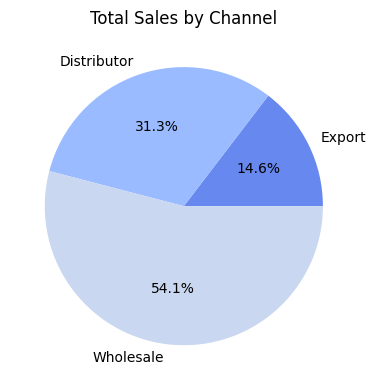

In [42]:
#sales by channel

channel_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=True)

plt.figure(figsize=(4,4))

plt.pie(
    channel_sales.values,
    labels=channel_sales.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('coolwarm')
)

plt.title('Total Sales by Channel')

plt.tight_layout()

plt.show()

# INSIGHTS
Wholesale accounts for 54 % of sales, with distributors at ~31 % and exports at ~15 %, underscoring reliance on domestic bulk channels.

To diversify revenue and mitigate concentration risk, prioritize expanding export initiatives—through targeted overseas marketing and strategic partner relationships.

# Total Sales by US Region
Goal: Compare total sales across U.S. regions to identify top‑performing markets and areas for targeted growth.

Chart: Horizontal bar chart

EDA Type: Univariate comparison

Structure:

Bars sorted ascending (Northeast → West) for clear bottom‑to‑top ranking
X‑axis in millions USD, Y‑axis listing regions

#  Recommendations
Outlier Strategy: Exclude or formalize bulk-order and promotional SKUs when calculating averages.

Margin Uplift: Apply top-product pricing levers to mid/low tiers; cut costs on underperformers.

Seasonal Planning: Shift spend toward January trough and May–June peak; investigate the 2017 anomaly.

Dashboard Prep: Build aggregated tables for time series, channel mix, and product performance for Power BI.